In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr

from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from joblib import Parallel, delayed

def build_mlp_pipeline(hidden_layer_sizes=(64, 32),
                       alpha=1e-3,
                       learning_rate_init=1e-3,
                       random_state=42):
    """
    Build a Pipeline: StandardScaler -> MLPRegressor
    with the given hyperparameters.
    """
    mlp = MLPRegressor(
        hidden_layer_sizes=hidden_layer_sizes,
        activation="relu",
        solver="adam",
        alpha=alpha,                  # L2 regularization
        learning_rate="adaptive",
        learning_rate_init=learning_rate_init,
        max_iter=300,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=10,
        random_state=random_state
    )
    return Pipeline([
        ("scaler", StandardScaler()),
        ("mlp", mlp)
    ])


def cv_tune_mlp_on_train(X_train, y_train,
                         param_grid,
                         n_splits=5,
                         random_state=42):
    """
    Hyperparameter tuning using K-fold CV on the 80% train set.

    For each hyperparameter configuration:
      - Run K-fold CV on (X_train, y_train)
      - Compute mean RMSE across folds
    Choose the configuration with the lowest mean RMSE.

    Returns:
      best_params (dict), best_mean_rmse (float)
    """
    cv = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    best_rmse = np.inf
    best_params = None

    for params in param_grid:
        fold_rmses = []

        for train_idx, val_idx in cv.split(X_train, y_train):
            X_tr, X_val = X_train[train_idx], X_train[val_idx]
            y_tr, y_val = y_train[train_idx], y_train[val_idx]

            model = build_mlp_pipeline(
                hidden_layer_sizes=params["hidden_layer_sizes"],
                alpha=params["alpha"],
                learning_rate_init=params["learning_rate_init"],
                random_state=random_state
            )

            model.fit(X_tr, y_tr)
            y_val_pred = model.predict(X_val)
            rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
            fold_rmses.append(rmse)

        mean_rmse = np.mean(fold_rmses)

        if mean_rmse < best_rmse:
            best_rmse = mean_rmse
            best_params = params

    return best_params, best_rmse


def run_tf_training_with_heldout_test(X, y, pert_name,
                                      train_idx,
                                      test_idx,
                                      param_grid,
                                      cv_splits=5,
                                      random_state=42):
    """
    For one TF (one target y):
      - Use global train_idx/test_idx to define 80%/20% split.
      - On the 80% (train) perform CV-based hyperparameter tuning.
      - Retrain best model on full 80%.
      - Evaluate once on the 20% held-out test set.
    """

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Hyperparameter tuning on train set only
    best_params, best_cv_rmse = cv_tune_mlp_on_train(
        X_train, y_train,
        param_grid=param_grid,
        n_splits=cv_splits,
        random_state=random_state
    )

    # Train final model on full 80% using best hyperparams
    final_model = build_mlp_pipeline(
        hidden_layer_sizes=best_params["hidden_layer_sizes"],
        alpha=best_params["alpha"],
        learning_rate_init=best_params["learning_rate_init"],
        random_state=random_state
    )
    final_model.fit(X_train, y_train)

    # Evaluate on the untouched 20%
    y_pred = final_model.predict(X_test)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    test_corr, _ = pearsonr(y_test, y_pred)

    return {
        "perturbation": pert_name,
        "rmse_test": test_rmse,
        "pearson_corr_test": test_corr,
        "cv_rmse_mean": best_cv_rmse,
        "hidden_layer_sizes": best_params["hidden_layer_sizes"],
        "alpha": best_params["alpha"],
        "learning_rate_init": best_params["learning_rate_init"]
    }

In [13]:

# ======================
# Load input data
# ======================
EMBEDDING_TYPE = "tss"  # or "gencode"

input_file = "../../../data/active_guides_CRISPRa_mean_pop_mean.csv"
mean_pop = pd.read_csv(input_file, index_col=0)

# Load embeddings and metadata based on selected type
if EMBEDDING_TYPE == "tss":
    embeddings_path = "../../../embeddings/embeddings_enformer_tss.npy"
    metadata_path = "../../../embeddings/enformer_gene_names.txt"
    print(f"Loading TSS embeddings from: {embeddings_path}")
elif EMBEDDING_TYPE == "gencode":
    embeddings_path = "../../../embeddings/embeddings_enformer_gencode.v49.pc_transcripts.npy"
    metadata_path = "../../../embeddings/gencode.v49.pc_transcripts_gene_names.txt"
    print(f"Loading Gencode v49 PC transcripts embeddings from: {embeddings_path}")
else:
    raise ValueError(f"Unknown embedding type: {EMBEDDING_TYPE}. Use 'tss' or 'gencode'.")

embeddings = np.load(embeddings_path, allow_pickle=True)
print(f"Embeddings shape: {embeddings.shape}")

meta_table = pd.read_csv(metadata_path, sep="\t", header=None, names=["index", "gene"])
print(f"Loaded {len(meta_table)} gene names from metadata")

embeddings = pd.DataFrame(embeddings, index=meta_table['gene'])

# Align datasets: same genes in embeddings and mean_pop
embeddings = embeddings.groupby(embeddings.index).mean()
embeddings.head()
common_genes = mean_pop.columns.intersection(embeddings.index)
X = embeddings.loc[common_genes]            # genes x features
Y = mean_pop[common_genes].T               # genes x perturbations

perturb_names = Y.columns

print("X shape:", X.shape, "| Y shape:", Y.shape)

# ======================
# Create a single 80/20 train/test split for genes
# ======================
n_genes = X.shape[0]
all_indices = np.arange(n_genes)

train_idx, test_idx = train_test_split(
    all_indices,
    test_size=0.2,
    shuffle=True,
    random_state=42
)

print(f"Train genes: {len(train_idx)}, Test genes: {len(test_idx)}")

# Convert X to numpy once
X_np = X.values



Loading TSS embeddings from: ../../../embeddings/embeddings_enformer_tss.npy
Embeddings shape: (19685, 32)
Loaded 19685 gene names from metadata
X shape: (4773, 32) | Y shape: (4773, 231)
Train genes: 3818, Test genes: 955


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
gencode_results = pd.read_csv("enformer_gencode_mlp_80_20_heldout_results_active_guides_CRISPRa_mean_pop_mean.csv.csv")
tss_results = pd.read_csv("enformer_tss_mlp_80_20_heldout_results_active_guides_CRISPRa_mean_pop_mean.csv.csv")
# Add embedding type label for plotting legend
gencode_results['embedding_type'] = 'gencode'
tss_results['embedding_type'] = 'tss'
# Combine resuts
combined_results = pd.concat([gencode_results, tss_results], ignore_index=True)

C:\Users\palak\AppData\Local\Temp\ipykernel_16124\256357681.py:2: FutureWarning: The provided callable <function mean at 0x0000017AC6A3CCC0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  agg_metrics = combined_results.groupby('embedding_type').agg({
C:\Users\palak\AppData\Local\Temp\ipykernel_16124\256357681.py:2: FutureWarning: The provided callable <function mean at 0x0000017AC6A3CCC0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  agg_metrics = combined_results.groupby('embedding_type').agg({


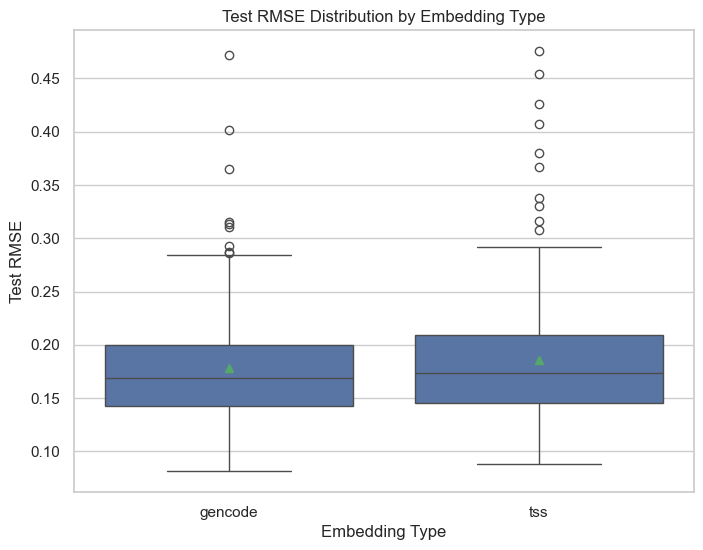

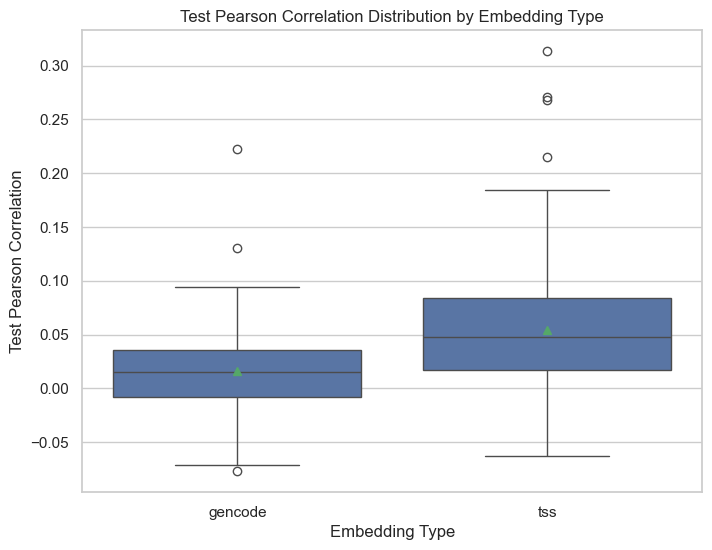

In [13]:

# Aggregate mean and standard error for metrics grouped by embedding type
agg_metrics = combined_results.groupby('embedding_type').agg({
    'rmse_test': [np.mean, lambda x: np.std(x)/np.sqrt(len(x))],
    'pearson_corr_test': [np.mean, lambda x: np.std(x)/np.sqrt(len(x))]
})

agg_metrics.columns = ['rmse_mean', 'rmse_se', 'pearson_mean', 'pearson_se']
agg_metrics = agg_metrics.reset_index()

# Plot boxplot for Test RMSE
plt.figure(figsize=(8, 6))
sns.boxplot(x='embedding_type', y='rmse_test', data=combined_results, showmeans=True)
plt.xlabel('Embedding Type')
plt.ylabel('Test RMSE')
plt.title('Test RMSE Distribution by Embedding Type')
plt.show()

# Plot boxplot for Test Pearson Correlation
plt.figure(figsize=(8, 6))
sns.boxplot(x='embedding_type', y='pearson_corr_test', data=combined_results, showmeans=True)
plt.xlabel('Embedding Type')
plt.ylabel('Test Pearson Correlation')
plt.title('Test Pearson Correlation Distribution by Embedding Type')
plt.show()


In [18]:
df = pd.read_csv("enformer_tss_mlp_80_20_heldout_embeddings_active_guides_CRISPRa_mean_pop_mean.csv.csv")
# Example structure check (uncomment if needed)
print(df.shape)
print(type(df.iloc[0, 0]))  # Should be np.ndarray or list with length 32


(231, 2)
<class 'str'>


In [22]:
import numpy as np
import pandas as pd
import ast  # For safely evaluating string representations of lists

# Example DataFrame structure:
# df['embedding'] contains list-of-list strings; each string needs conversion

def convert_and_flatten_embedding(embedding_str):
    # Convert string representation to list of lists
    embedding_list = ast.literal_eval(embedding_str)
    # Flatten list of lists into a single 1D array
    flattened = np.array(embedding_list).flatten()
    return flattened

# Assuming your DataFrame is named df and 'embedding_column' is the name of this column
# For example, if column name is 'Yembedding0' or 'embedding'
df['embedding_flat'] = df['embedding'].apply(convert_and_flatten_embedding)

# Now create a DataFrame where each row is a flattened embedding vector
flattened_embeddings = pd.DataFrame(df['embedding_flat'].tolist(), index=df.Y)

print(flattened_embeddings.shape)
# This DataFrame is ready for clustering or other analyses


(231, 30560)


In [27]:
df.head()

,Y,embedding,embedding_flat
0,AFF1,"[[0.0, 0.0, 0.43620213866233826, 0.0, 0.0, 0.0...","[0.0, 0.0, 0.43620213866233826, 0.0, 0.0, 0.0,..."
1,ALX1,"[[0.07655773311853409, 0.06866493821144104, 0....","[0.07655773311853409, 0.06866493821144104, 0.5..."
2,ALX4,"[[0.031040765345096588, 0.0, 0.467318147420883...","[0.031040765345096588, 0.0, 0.4673181474208832..."
3,ARID1A,"[[0.09441271424293518, 0.0, 0.4041377305984497...","[0.09441271424293518, 0.0, 0.4041377305984497,..."
4,ARID3A,"[[0.0, 0.0, 0.46831926703453064, 0.0, 0.0, 0.0...","[0.0, 0.0, 0.46831926703453064, 0.0, 0.0, 0.0,..."


In [26]:
flattened_embeddings.head()

,0,1,2,3,4,5,6,7,8,9,...,30550,30551,30552,30553,30554,30555,30556,30557,30558,30559
Y,,,,,,,,,,,,,,,,,,,,,
AFF1,0.000000,0.000000,0.436202,0.0,0.0,0.0,0.0,0.027182,0.0,0.0,...,0.0,0.0,0.080754,0.000000,0.0,0.0,0.0,0.123705,0.0,0.0
ALX1,0.076558,0.068665,0.533383,0.0,0.0,0.0,0.0,0.140512,0.0,0.0,...,0.0,0.0,0.093479,0.005012,0.0,0.0,0.0,0.000000,0.0,0.0
ALX4,0.031041,0.000000,0.467318,0.0,0.0,0.0,0.0,0.144210,0.0,0.0,...,0.0,0.0,0.012073,0.042103,0.0,0.0,0.0,0.000000,0.0,0.0
ARID1A,0.094413,0.000000,0.404138,0.0,0.0,0.0,0.0,0.113346,0.0,0.0,...,0.0,0.0,0.041241,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0
ARID3A,0.000000,0.000000,0.468319,0.0,0.0,0.0,0.0,0.093869,0.0,0.0,...,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0


In [40]:
# flattened_df: rows = cell types, columns = concatenated gene embeddings (features)

def log_normalize(df, scale_factor=1e4):
    # Sum of all features per cell type
    total_per_cell = df.sum(axis=1)
    # Normalize per cell type vector
    normalized = df.div(total_per_cell, axis=0) * scale_factor
    # Log1p transform (log(1+x))
    log_normalized = np.log1p(normalized)
    return log_normalized

lognorm_df = log_normalize(flattened_embeddings)


In [88]:
def find_variable_features(df, n_top=5000):
    # Mean and variance per feature
    means = df.mean(axis=0)
    vars_ = df.var(axis=0)
    # Compute coefficient of variation squared (CV^2 = var / mean^2)
    cv2 = vars_ / (means ** 2 + 1e-8)  # add small number to avoid divide by zero
    
    # Optionally model mean-variance trend and select genes above trend,
    # but here we just pick top features by variance
    top_features = cv2.sort_values(ascending=False).head(n_top).index
    return df[top_features]

hvf_df = find_variable_features(lognorm_df, n_top=10000)

In [89]:
def scale_data(df):
    means = df.mean(axis=0)
    stds = df.std(axis=0)
    scaled_df = (df - means) / stds
    return scaled_df

scaled_df = scale_data(hvf_df)


In [90]:
from sklearn.decomposition import PCA

pca = PCA(n_components=20, random_state=42)
pca_result = pca.fit_transform(scaled_df.values)

explained_variance_ratio = pca.explained_variance_ratio_


In [91]:
explained_variance_ratio

array([0.67969473, 0.13499795, 0.01424319, 0.00925639, 0.0084264 ,
       0.0073232 , 0.00646754, 0.00558267, 0.00524746, 0.00418891,
       0.00399839, 0.00393306, 0.00333092, 0.00326989, 0.00322563,
       0.00310675, 0.00290439, 0.00266593, 0.00244224, 0.00232129])

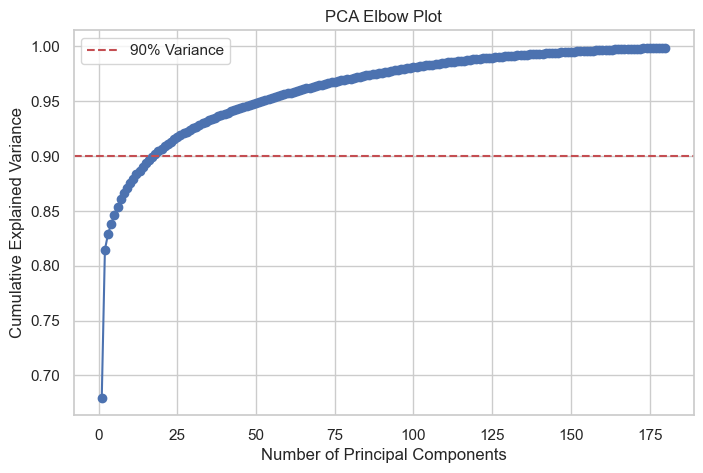

In [92]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np

# Assume X_scaled is your normalized data matrix (samples x features)

# Fit PCA with max number of components equal to number of features or a specified max
max_components = min(scaled_df.shape[1], 180)  # limit for visualization (e.g. 50)
pca = PCA(n_components=max_components, random_state=42)
pca.fit(scaled_df)

explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

plt.figure(figsize=(8, 5))
plt.plot(range(1, max_components + 1), cumulative_variance, marker='o')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Elbow Plot')
plt.grid(True)
plt.axhline(y=0.9, color='r', linestyle='--', label='90% Variance')
plt.legend()
plt.show()


c:\Users\palak\miniconda3\envs\myenv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


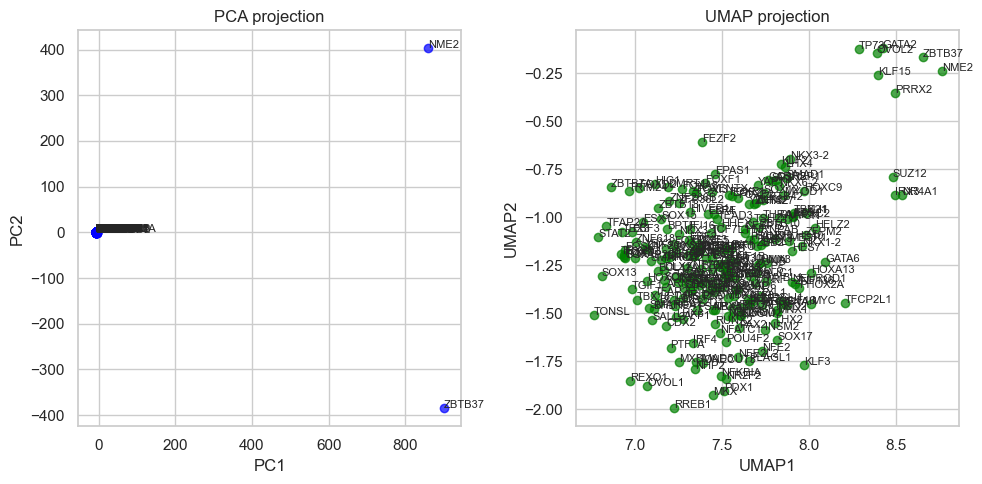

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import umap
from sklearn.preprocessing import StandardScaler

# Standardize embeddings before PCA/UMAP
scaler = StandardScaler()
X_scaled = scaler.fit_transform(flattened_embeddings)

# Assuming 'flattened_embeddings' DataFrame:
# rows = cell types, columns = flattened embedding features
# Also, assume your original df index has cell type names for labeling

# Step 1: PCA to 2 components
pca = PCA(n_components=10, random_state=42)
pca_result = pca.fit_transform(scaled_df)

# Step 2: UMAP to 2 components
umap_reducer = umap.UMAP(n_components=10, random_state=42)
umap_result = umap_reducer.fit_transform(scaled_df)

# Plot PCA result
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.scatter(pca_result[:, 0], pca_result[:, 1], c='blue', alpha=0.7)
plt.title("PCA projection")
plt.xlabel("PC1")
plt.ylabel("PC2")
for i, celltype in enumerate(flattened_embeddings.index):
    plt.text(pca_result[i, 0], pca_result[i, 1], celltype, fontsize=8)

# Plot UMAP result
plt.subplot(1, 2, 2)
plt.scatter(umap_result[:, 0], umap_result[:, 1], c='green', alpha=0.7)
plt.title("UMAP projection")
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
for i, celltype in enumerate(flattened_embeddings.index):
    plt.text(umap_result[i, 0], umap_result[i, 1], celltype, fontsize=8)

plt.tight_layout()
plt.show()


c:\Users\palak\miniconda3\envs\myenv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


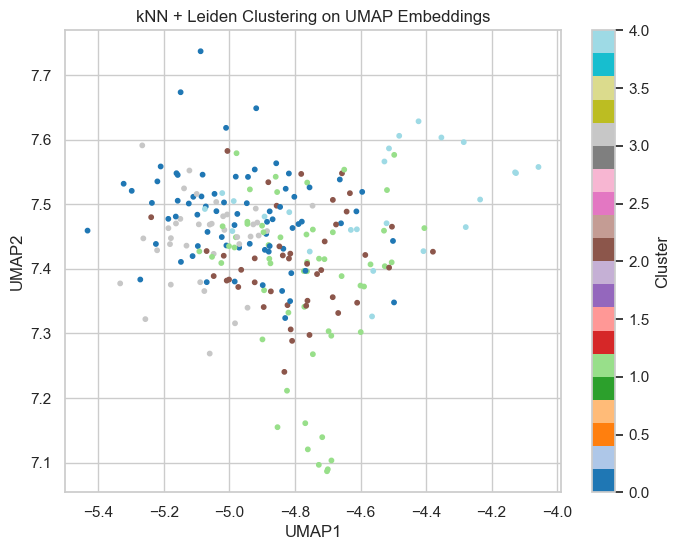

In [ ]:
import umap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import kneighbors_graph
import networkx as nx
import leidenalg
import igraph as ig

# Assume scaled_df is your scaled data matrix (cells x features)

# Step 1: UMAP embedding
umap_reducer = umap.UMAP(n_components=70, random_state=42)
umap_embedding = umap_reducer.fit_transform(scaled_df)


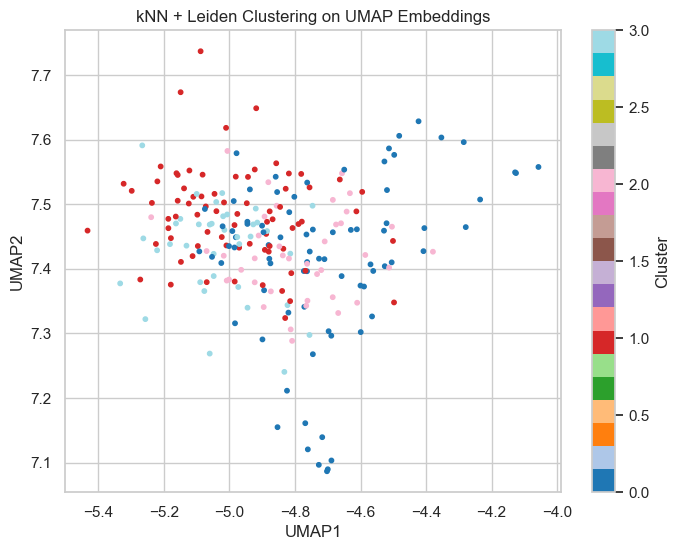

In [131]:

# Step 2: Build kNN graph on UMAP embeddings
k = 15 # choose k neighbors
knn_graph = kneighbors_graph(umap_embedding, n_neighbors=k, mode='connectivity', include_self=False)

# Convert sparse matrix to igraph graph for leiden
sources, targets = knn_graph.nonzero()
edges = list(zip(sources, targets))
graph = ig.Graph(edges=edges, directed=False)

# Step 3: Cluster using Leiden algorithm
partition = leidenalg.find_partition(graph, leidenalg.ModularityVertexPartition)

# Cluster membership labels
labels = np.array(partition.membership)

# Plot UMAP colored by cluster
plt.figure(figsize=(8,6))
scatter = plt.scatter(umap_embedding[:,0], umap_embedding[:,1], c=labels, cmap='tab20', s=10)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')
plt.title('kNN + Leiden Clustering on UMAP Embeddings')
# for i, celltype in enumerate(flattened_embeddings.index):
#     plt.text(umap_result[i, 0], umap_result[i, 1], celltype, fontsize=8)

plt.show()
